# SNAP-a score vs. Ast15 score comparison

This notebook compares the SNAP-a score (from loadings) with the Ast15 module score across Schizophrenia (SCZ) and Control samples. It also examines the correlation shifts between these astrocyte markers and microglia modules.

In [1]:
import os
import sys
import pandas as pd
import scanpy as sc
import numpy as np
from scipy.stats import pearsonr

# Add sources to path
sys.path.append(os.path.abspath('../../sources'))

import snap_utils, wgcna_utils

/data/home/swkim0523/.local/lib/python3.9/site-packages/setuptools_scm/version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import iter_entry_points


## 1. Load Data and Settings

In [2]:
project_root = '../..'
data_dir = os.path.join(project_root, 'data/primary_cohort')
wgcna_dir = os.path.join(data_dir, 'WGCNA_modules')
pb_filtered_dir = os.path.join(data_dir, 'pb_ct_filtered')

# Paths
snap_loading_path = os.path.join(data_dir, '../SNAP_loadings/41586_2024_7109_MOESM10_ESM.xlsx')

pb_astro_ctrl_avg_path = os.path.join(data_dir, 'pb_ct/pb_astrocyte_control_avg.h5ad')
pb_astro_scz_avg_path = os.path.join(data_dir, 'pb_ct/pb_astrocyte_scz_avg.h5ad')

pb_astro_ctrl_filtered_path = os.path.join(pb_filtered_dir, 'pb_astrocyte_control_filtered.csv')
pb_astro_scz_filtered_path = os.path.join(pb_filtered_dir, 'pb_astrocyte_scz_filtered.csv')

pb_mic_ctrl_filtered_path = os.path.join(pb_filtered_dir, 'pb_microglia_control_filtered.csv')
pb_mic_scz_filtered_path = os.path.join(pb_filtered_dir, 'pb_microglia_scz_filtered.csv')

z_summary_thres = 2

## 2. Calculate Module Scores

In [4]:
# Load astrocyte module dictionary using wgcna_utils
astro_modules, _, _ = wgcna_utils.get_module_dict(
    ct='astrocyte', 
    z_summary_path=os.path.join(wgcna_dir, 'df_zsummary_astrocyte.csv'), 
    module_csv_path=os.path.join(wgcna_dir, 'modules_whole_astrocyte.csv'), 
    z_summary_thres=z_summary_thres
)

# Load filtered pseudobulk data and calculate module means
df_astro_ctrl_filtered = pd.read_csv(pb_astro_ctrl_filtered_path, index_col=0)
df_astro_scz_filtered = pd.read_csv(pb_astro_scz_filtered_path, index_col=0)

ast_control_means = snap_utils.get_module_means(df_astro_ctrl_filtered, astro_modules, 'Ast')
ast_scz_means = snap_utils.get_module_means(df_astro_scz_filtered, astro_modules, 'Ast')

# Load microglia module dictionary
mic_modules, _, _= wgcna_utils.get_module_dict(
    ct='microglia', 
    z_summary_path=os.path.join(wgcna_dir, 'df_zsummary_microglia.csv'), 
    module_csv_path=os.path.join(wgcna_dir, 'modules_whole_microglia.csv'), 
    z_summary_thres=z_summary_thres
)

# Load filtered pseudobulk data for Microglia and calculate module means
df_mic_ctrl_filtered = pd.read_csv(pb_mic_ctrl_filtered_path, index_col=0)
df_mic_scz_filtered = pd.read_csv(pb_mic_scz_filtered_path, index_col=0)

mic_control_means = snap_utils.get_module_means(df_mic_ctrl_filtered, mic_modules, 'Mic')
mic_scz_means = snap_utils.get_module_means(df_mic_scz_filtered, mic_modules, 'Mic')

Module 1: 474 genes
Module 2: 2888 genes
Module 3: 992 genes
Module 4: 195 genes
Module 5: 74 genes
Module 7: 618 genes
Module 8: 284 genes
Module 9: 126 genes
Module 10: 165 genes
Module 11: 104 genes
Module 12: 103 genes
Module 13: 322 genes
Module 14: 180 genes
Module 15: 363 genes
Module 16: 593 genes
Module 17: 247 genes
Module 18: 251 genes
Module 19: 3575 genes
Module 20: 723 genes
[module 1] used 474/474 genes.
[module 2] used 2888/2888 genes.
[module 3] used 992/992 genes.
[module 4] used 195/195 genes.
[module 5] used 74/74 genes.
[module 7] used 618/618 genes.
[module 8] used 284/284 genes.
[module 9] used 126/126 genes.
[module 10] used 165/165 genes.
[module 11] used 104/104 genes.
[module 12] used 103/103 genes.
[module 13] used 322/322 genes.
[module 14] used 180/180 genes.
[module 15] used 363/363 genes.
[module 16] used 593/593 genes.
[module 17] used 247/247 genes.
[module 18] used 251/251 genes.
[module 19] used 3575/3575 genes.
[module 20] used 723/723 genes.
[modul

## 3. Calculate SNAP-a Scores

In [5]:
# Load SNAP loadings
loadings = pd.read_excel(snap_loading_path, sheet_name='Gene loadings', index_col='Gene')

# Load average pseudobulk data
pb_ct_astro_ctrl = sc.read_h5ad(pb_astro_ctrl_avg_path)
pb_ct_astro_scz = sc.read_h5ad(pb_astro_scz_avg_path)

# Calculate SNAP-a score
snap_utils.snap_score_calc(pb_ct_astro_ctrl, loadings)
snap_utils.snap_score_calc(pb_ct_astro_scz, loadings)

## 4. Ast15 vs SNAP-a Comparison Plot

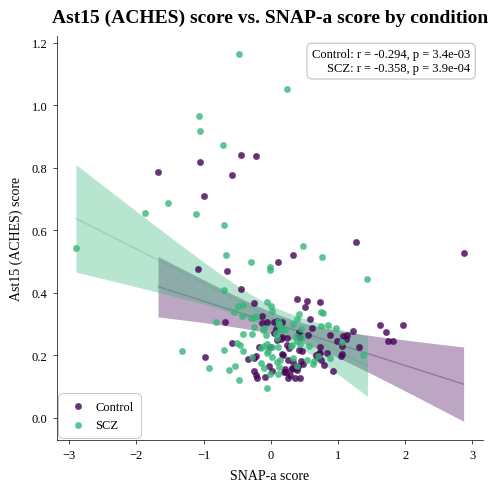

In [6]:
# Prepare combined DataFrame
df_combined = pd.DataFrame({
    "SNAP_a": pd.concat([
        pb_ct_astro_ctrl.obs["SNAP_a_score"],
        pb_ct_astro_scz.obs["SNAP_a_score"],
    ]),
    "Ast15": pd.concat([
        ast_control_means["Ast15"],
        ast_scz_means["Ast15"],
    ]),
    "Condition": (
        ["Control"] * len(pb_ct_astro_ctrl)
        + ["SCZ"] * len(pb_ct_astro_scz)
    ),
})

# Calculate correlations per condition
stats = {}
for cond, sub in df_combined.groupby("Condition"):
    sub_clean = sub.dropna(subset=["SNAP_a", "Ast15"])
    r, p = pearsonr(sub_clean["SNAP_a"], sub_clean["Ast15"])
    stats[cond] = (r, p)

# VIRIDIS palette endpoints
palette = {
    "Control": "#440154",
    "SCZ":     "#35B779",
}

# Plot
snap_utils.plot_snap_ast_scatter(
    df_combined, 
    x_col="SNAP_a", 
    y_col="Ast15", 
    condition_col="Condition", 
    stats=stats, 
    palette=palette,
    output_path="../../figures/fig3c_ast15_snapa_scatter"
)

## 5. Correlation Shift Analysis (Astrocyte markers – Microglia modules)

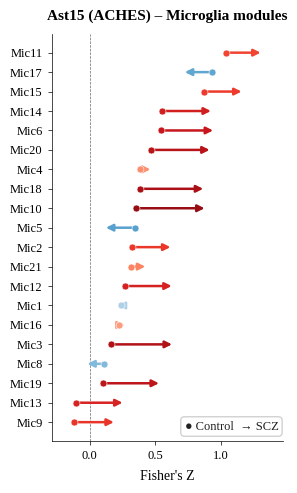

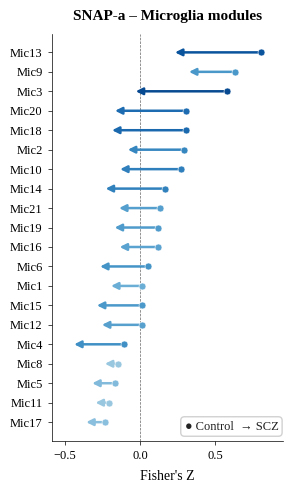

In [7]:
def fisher_z(r):
    r = np.clip(r, -0.999999, 0.999999)
    return 0.5 * np.log((1 + r) / (1 - r))

def get_z_series(marker_ctrl, marker_scz, mic_ctrl, mic_scz):
    # marker_ctrl/scz: pd.Series of marker scores (index = donors)
    # mic_ctrl/scz: pd.DataFrame of microglia module scores (index = donors)
    
    common_ctrl = marker_ctrl.index.intersection(mic_ctrl.index)
    common_scz = marker_scz.index.intersection(mic_scz.index)
    
    z_ctrl = {}
    z_scz = {}
    
    for col in mic_ctrl.columns:
        r_c, _ = pearsonr(marker_ctrl.loc[common_ctrl], mic_ctrl.loc[common_ctrl, col])
        r_s, _ = pearsonr(marker_scz.loc[common_scz], mic_scz.loc[common_scz, col])
        z_ctrl[col] = fisher_z(r_c)
        z_scz[col] = fisher_z(r_s)
        
    return pd.Series(z_ctrl), pd.Series(z_scz)

# 5.1. Ast15 - Mic shift (Fig 3a)
z_ast_ctrl, z_ast_scz = get_z_series(
    ast_control_means["Ast15"], 
    ast_scz_means["Ast15"], 
    mic_control_means, 
    mic_scz_means
)

snap_utils.plot_correlation_shift_arrows(
    z_ast_ctrl, z_ast_scz, 
    title="Ast15 (ACHES) – Microglia modules",
    output_path="../../figures/fig3a_ast15_mic_arrow"
)

# 5.2. SNAP-a - Mic shift (Fig 3b)
z_snap_ctrl, z_snap_scz = get_z_series(
    pb_ct_astro_ctrl.obs["SNAP_a_score"], 
    pb_ct_astro_scz.obs["SNAP_a_score"], 
    mic_control_means, 
    mic_scz_means
)

snap_utils.plot_correlation_shift_arrows(
    z_snap_ctrl, z_snap_scz, 
    title="SNAP-a – Microglia modules",
    output_path="../../figures/fig3b_snapa_mic_arrow"
)

In [8]:
import math 
import numpy as np
def fisher_z(r):
    """
    Fisher Z-transformation of correlation coefficient.
    """
    r = np.clip(r, -0.999999, 0.999999)
    return 0.5 * np.log((1 + r) / (1 - r))

(fisher_z(-0.294) - fisher_z(-0.358)) / math.sqrt((1/(97-3)) +(1/(94-3)))

np.float64(0.48721461595706506)

In [14]:
import numpy as np
from scipy.stats import norm

def calculate_delta_corr_significance(r1_matrix, n1, r2_matrix, n2):
    """
    Calculate difference in correlations (Fisher Z transformed), 
    z-scores, and associated two-tailed p-values.
    """
    z1 = fisher_z(r1_matrix)
    z2 = fisher_z(r2_matrix)
    
    delta_z = z1 - z2
    
    # Standard error of difference between two independent Fisher Z scores
    se = np.sqrt(1/(n1-3) + 1/(n2-3))
    
    z_scores = delta_z / se
    
    # 양측 검정(two-tailed test) p-value 계산
    # norm.sf(x)는 1 - norm.cdf(x)와 같으며 수치적으로 더 안정적입니다.
    p_values = 2 * norm.sf(np.abs(z_scores))

    return z_scores, p_values


In [32]:
z_scores, p_values = calculate_delta_corr_significance(z_snap_ctrl, 97, z_snap_scz, 94)
delta_z = z_snap_scz - z_snap_ctrl
df_long = pd.DataFrame({
    'delta_z': delta_z,
    'p_value': p_values
}).reset_index()
df_long.to_csv('../../data/primary_cohort/corr_diff/corr_diff_ACHES-Mic_modules.csv', index=False)
